# EDA — Gene Expression Data (CCLE)

**Goal**: Understand the gene expression dataset deeply enough to make principled decisions about modelling for two tasks:
- **Task 1** — Binary classification: TP53 mutant vs. wild-type
- **Task 2** — Multi-class classification of TP53 mutation subtypes

We go step by step. Each section ends with a short **Key Takeaway** box summarising what we learned and why it matters for modelling.

---
**Data used here**: CCLE (Cancer Cell Line Encyclopedia) — raw CSV files  
- `OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv` — log₂(TPM+1) expression matrix  
- `OmicsSomaticMutations.csv` — somatic mutation calls  
**Friend's parallel notebook**: TCGA data (same structure, different cohort)

## 0. Setup

In [43]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ── Paths ────────────────────────────────────────────────────────────────────
# notebook lives at <project_root>/notebooks/gene_expression/
NOTEBOOK_DIR = Path(os.getcwd())
PROJECT_ROOT = NOTEBOOK_DIR.parent.parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"

print(f"Project root : {PROJECT_ROOT}")
print(f"Data dir     : {DATA_DIR}")
assert DATA_DIR.exists(), "Data directory not found — check PROJECT_ROOT"

# ── Plot style ───────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
BINARY_PALETTE = {0: "steelblue", 1: "tomato"}   # 0=WT, 1=Mutant
SEED = 42
np.random.seed(SEED)

Project root : /Users/juliavikremoy/Desktop/tp53-mutation-predictor
Data dir     : /Users/juliavikremoy/Desktop/tp53-mutation-predictor/data/raw


---
## 1. Load Data

In [44]:
# ── 1a. Expression matrix ─────────────────────────────────────────────────────
_EXPR_META = ["SequencingID", "ModelConditionID", "IsDefaultEntryForMC", "IsDefaultEntryForModel"]

expr_raw = pd.read_csv(DATA_DIR / "OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv", index_col=0)
expr = (
    expr_raw[expr_raw["IsDefaultEntryForModel"] == "Yes"]
    .set_index("ModelID")
    .drop(columns=_EXPR_META)
)

# ── 1b. Mutations — TP53 only, default entries ────────────────────────────────
muts_raw = pd.read_csv(DATA_DIR / "OmicsSomaticMutations.csv", index_col=0, low_memory=False)
muts = (
    muts_raw[
        (muts_raw["IsDefaultEntryForModel"] == "Yes") &
        (muts_raw["HugoSymbol"] == "TP53")
    ]
    .reset_index(drop=True)
)

# ── 1c. Derive per-cell-line TP53 labels ──────────────────────────────────────
def _classify_tp53(mc_values):
    """Classify TP53 status from a cell line's MolecularConsequence strings.
    Priority: Frame_Shift_Del > Splice_Site > Missense_Mutation > Other."""
    terms = set()
    for mc in mc_values:
        for part in str(mc).split(","):
            terms.add(part.split("|")[-1].strip())
    if any("frameshift" in t for t in terms):
        return "Frame_Shift_Del"
    if any(t in ("splice_donor_variant", "splice_acceptor_variant") for t in terms):
        return "Splice_Site"
    if any("missense" in t for t in terms):
        return "Missense_Mutation"
    return "Other"

tp53_class_per_cell = muts.groupby("ModelID")["MolecularConsequence"].apply(_classify_tp53)

labels = pd.DataFrame(index=expr.index)
labels["tp53_binary"] = labels.index.isin(tp53_class_per_cell.index).astype(int)
labels["tp53_class"]  = labels.index.map(tp53_class_per_cell).fillna("WT")
labels["lineage"]     = None

print(f"Expression matrix     : {expr.shape[0]:,} cell lines  ×  {expr.shape[1]:,} genes")
print(f"Labels                : {labels.shape}")
print(f"TP53 mutation records : {muts.shape}")
print()
print("Label distribution:")
print(labels["tp53_class"].value_counts())

Expression matrix     : 1,719 cell lines  ×  19,215 genes
Labels                : (1719, 3)
TP53 mutation records : (1324, 68)

Label distribution:
tp53_class
WT                   722
Missense_Mutation    636
Other                236
Splice_Site           67
Frame_Shift_Del       58
Name: count, dtype: int64


---
## 2. Dataset Overview — Shape, Types, Missing Values

In [45]:
# ── 2a. Label columns ────────────────────────────────────────────────────────
print("Label columns and dtypes:")
print(labels.dtypes)
print()
print("First 5 rows of labels:")
labels.head()

Label columns and dtypes:
tp53_binary     int64
tp53_class     object
lineage        object
dtype: object

First 5 rows of labels:


,tp53_binary,tp53_class,lineage
ModelID,,,
ACH-001113,1,Missense_Mutation,None
ACH-001289,0,WT,None
ACH-001339,1,Missense_Mutation,None
ACH-001979,0,WT,None
ACH-002438,0,WT,None


In [46]:
# ── 2b. Missing values in expression matrix ───────────────────────────────────
n_missing_cells = expr.isna().sum().sum()
n_missing_genes = (expr.isna().any()).sum()
print(f"Missing values in expression matrix : {n_missing_cells:,} cells across {n_missing_genes} genes")

# ── 2c. Missing values in labels ────────────────────────────────────────────
print()
print("Missing values per label column:")
print(labels.isna().sum())

Missing values in expression matrix : 0 cells across 0 genes

Missing values per label column:
tp53_binary       0
tp53_class        0
lineage        1719
dtype: int64


> **Key Takeaway 2**: Record any missing data here. If the expression matrix has no NaNs we won't need imputation. Missing lineage info means we can't stratify by tissue at this stage.

---
## 3. Label Analysis

We need to understand class balance before choosing a loss function or evaluation metric.

Binary label counts (0=WT, 1=Mutant):
             count   pct
tp53_binary             
0              722  42.0
1              997  58.0

Imbalance ratio  (mutant : WT) = 997:722 = 1.38


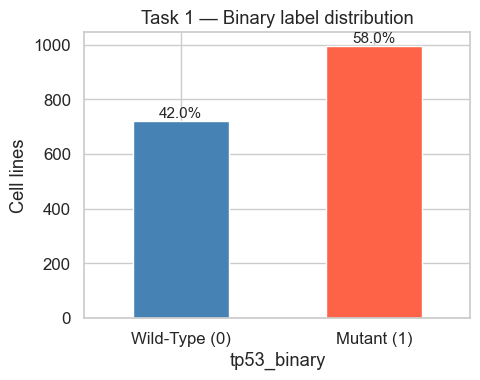

In [47]:
# ── 3a. Binary label distribution ────────────────────────────────────────────
binary_counts = labels["tp53_binary"].value_counts().sort_index()
binary_pct    = (binary_counts / len(labels) * 100).round(1)

print("Binary label counts (0=WT, 1=Mutant):")
print(pd.DataFrame({"count": binary_counts, "pct": binary_pct}))
print()
print(f"Imbalance ratio  (mutant : WT) = {binary_counts[1]}:{binary_counts[0]} = {binary_counts[1]/binary_counts[0]:.2f}")

fig, ax = plt.subplots(figsize=(5, 4))
binary_counts.plot.bar(ax=ax, color=[BINARY_PALETTE[i] for i in binary_counts.index], edgecolor="white")
ax.set_xticklabels(["Wild-Type (0)", "Mutant (1)"], rotation=0)
ax.set_ylabel("Cell lines")
ax.set_title("Task 1 — Binary label distribution")
for bar, pct in zip(ax.patches, binary_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f"{pct}%", ha="center", fontsize=11)
plt.tight_layout()
plt.show()

Multi-class label counts:
                   count   pct
tp53_class                    
WT                   722  42.0
Missense_Mutation    636  37.0
Other                236  13.7
Splice_Site           67   3.9
Frame_Shift_Del       58   3.4


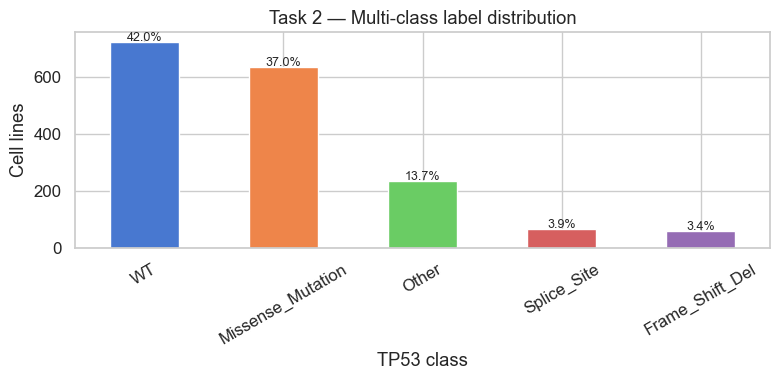

In [48]:
# ── 3b. Multi-class label distribution ───────────────────────────────────────
class_counts = labels["tp53_class"].value_counts()
class_pct    = (class_counts / len(labels) * 100).round(1)

print("Multi-class label counts:")
print(pd.DataFrame({"count": class_counts, "pct": class_pct}))

fig, ax = plt.subplots(figsize=(8, 4))
class_counts.plot.bar(ax=ax, color=sns.color_palette("muted", len(class_counts)), edgecolor="white")
ax.set_xlabel("TP53 class")
ax.set_ylabel("Cell lines")
ax.set_title("Task 2 — Multi-class label distribution")
ax.tick_params(axis="x", rotation=30)
for bar, pct in zip(ax.patches, class_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{pct}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

Create a sample with equal sizes of the classes
Stategies to overcome the issues

> **Key Takeaway 3**: Note the class balance ratio. If Task 1 is roughly 50/50 → accuracy is a fair metric. If heavily imbalanced → use AUC-ROC + F1, consider class-weight balancing. For Task 2, expect rare classes → macro F1 is the right metric, and we may need to merge very small classes or use oversampling.

---
## 4. Expression Value Distributions

Understanding the overall distribution of log2(TPM+1) values is critical. We expect a roughly log-normal shape with a spike at zero (unexpressed genes).

/var/folders/m0/s69y3ckx725_xdsv398tpyqr0000gn/T/ipykernel_64733/3861242455.py:19: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  plt.tight_layout()
/Users/juliavikremoy/opt/anaconda3/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


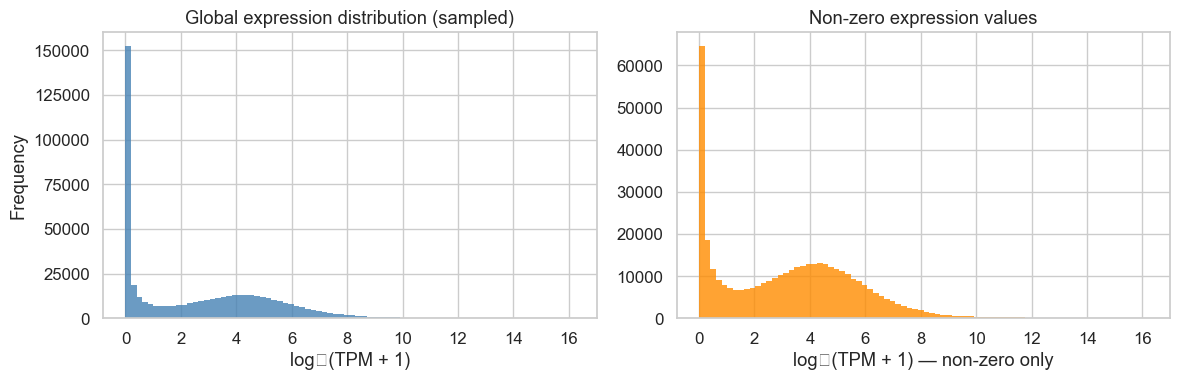

Fraction of zero values in expression matrix: 17.6%
Overall stats — mean: 2.670  median: 2.415  std: 2.549


In [49]:
# ── 4a. Global value distribution (random sample of values for speed) ─────────
flat_sample = expr.values.ravel()
flat_sample = flat_sample[~np.isnan(flat_sample)]
# sample 500k values for plotting speed
idx = np.random.choice(len(flat_sample), size=min(500_000, len(flat_sample)), replace=False)
sample = flat_sample[idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(sample, bins=80, color="steelblue", alpha=0.8, edgecolor="none")
axes[0].set_xlabel("log₂(TPM + 1)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Global expression distribution (sampled)")

axes[1].hist(sample[sample > 0], bins=80, color="darkorange", alpha=0.8, edgecolor="none")
axes[1].set_xlabel("log₂(TPM + 1) — non-zero only")
axes[1].set_title("Non-zero expression values")

plt.tight_layout()
plt.show()

pct_zero = (flat_sample == 0).mean() * 100
print(f"Fraction of zero values in expression matrix: {pct_zero:.1f}%")
print(f"Overall stats — mean: {flat_sample.mean():.3f}  median: {np.median(flat_sample):.3f}  std: {flat_sample.std():.3f}")

/var/folders/m0/s69y3ckx725_xdsv398tpyqr0000gn/T/ipykernel_64733/1598965889.py:9: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  plt.tight_layout()
/Users/juliavikremoy/opt/anaconda3/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


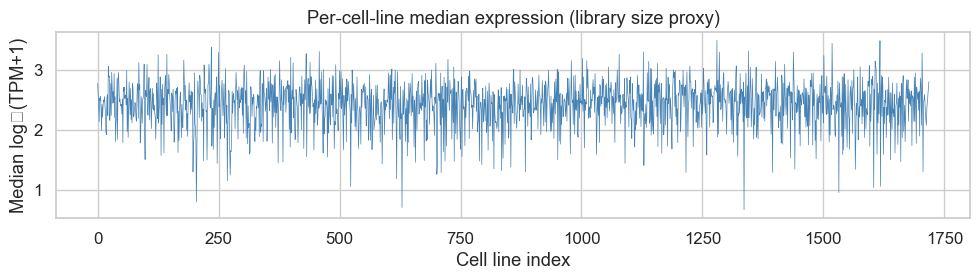

Per-cell median expression — mean: 2.418  std: 0.378
Range: [0.666, 3.485]


In [50]:
# ── 4b. Per-cell-line median expression (library size proxy) ─────────────────
cell_medians = expr.median(axis=1)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(cell_medians.values, linewidth=0.5, color="steelblue")
ax.set_xlabel("Cell line index")
ax.set_ylabel("Median log₂(TPM+1)")
ax.set_title("Per-cell-line median expression (library size proxy)")
plt.tight_layout()
plt.show()

print(f"Per-cell median expression — mean: {cell_medians.mean():.3f}  std: {cell_medians.std():.3f}")
print(f"Range: [{cell_medians.min():.3f}, {cell_medians.max():.3f}]")

> **Key Takeaway 4**: If >40% values are zero we have a highly sparse matrix — sparse-aware models or gene filtering will be important. High variance in per-cell medians suggests further normalisation (e.g., quantile normalisation) may help, but since data is already log2(TPM+1) this is usually fine.

---
## 5. Gene-Level Statistics — Variance & Mean–Variance Relationship

Most genes won't carry signal. We'll look at the variance distribution to decide how many genes to keep for modelling.

In [51]:
gene_mean = expr.mean(axis=0)
gene_var  = expr.var(axis=0)
gene_std  = expr.std(axis=0)

print(f"Total genes: {len(gene_var):,}")
for pct in [25, 50, 75, 90, 95, 99]:
    print(f"  {pct}th percentile variance: {np.percentile(gene_var, pct):.4f}")

Total genes: 19,215
  25th percentile variance: 0.3676
  50th percentile variance: 0.6192
  75th percentile variance: 1.3166
  90th percentile variance: 2.6618
  95th percentile variance: 3.8666
  99th percentile variance: 7.2161


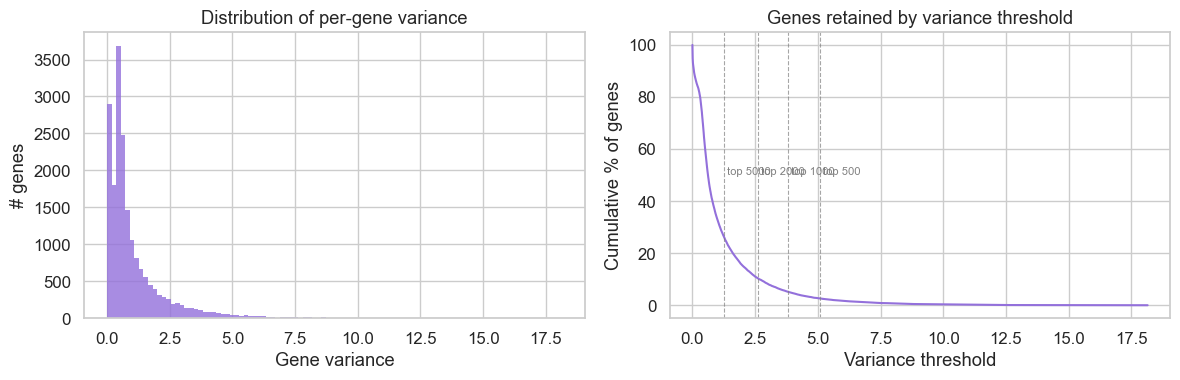

In [52]:
# ── 5a. Variance distribution ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(gene_var, bins=100, color="mediumpurple", alpha=0.8, edgecolor="none")
axes[0].set_xlabel("Gene variance")
axes[0].set_ylabel("# genes")
axes[0].set_title("Distribution of per-gene variance")

# cumulative % of genes by variance threshold
sorted_var = np.sort(gene_var)[::-1]
cum_pct = np.arange(1, len(sorted_var)+1) / len(sorted_var) * 100
axes[1].plot(sorted_var, cum_pct, color="mediumpurple", linewidth=1.5)
for n in [500, 1000, 2000, 5000]:
    v = sorted_var[n-1]
    axes[1].axvline(v, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
    axes[1].text(v, 50, f" top {n}", fontsize=8, color="gray")
axes[1].set_xlabel("Variance threshold")
axes[1].set_ylabel("Cumulative % of genes")
axes[1].set_title("Genes retained by variance threshold")

plt.tight_layout()
plt.show()

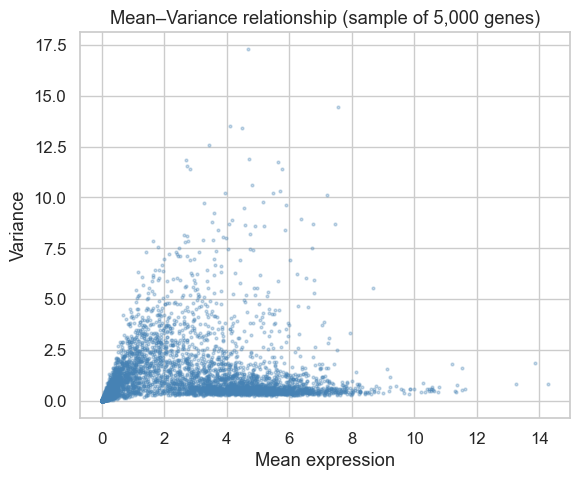

In [53]:
# ── 5b. Mean–variance relationship ──────────────────────────────────────────
# Subsample genes for plotting speed
idx = np.random.choice(len(gene_mean), size=min(5000, len(gene_mean)), replace=False)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(gene_mean.iloc[idx], gene_var.iloc[idx], s=4, alpha=0.3, color="steelblue")
ax.set_xlabel("Mean expression")
ax.set_ylabel("Variance")
ax.set_title("Mean–Variance relationship (sample of 5,000 genes)")
plt.tight_layout()
plt.show()

> **Key Takeaway 5**: The top variance genes are the most informative. A common starting point is **top 2,000 most variable genes** — enough signal, few enough for fast training. If the mean-variance plot shows a heteroscedastic relationship (variance increases with mean) this is expected for count data; log2(TPM+1) usually stabilises this.

---
## 6. Dimensionality Reduction — PCA

PCA on the top variable genes gives us an overview: can the data separate WT from mutant in low dimensions? This is the single most important exploratory step before modelling.

In [54]:
N_TOP_GENES = 2000
N_PCS       = 50

top_genes = gene_var.nlargest(N_TOP_GENES).index
X = expr[top_genes].values

# standardise before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=N_PCS, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA fitted on {N_TOP_GENES} top-variance genes, {N_PCS} components")
cum_var = np.cumsum(pca.explained_variance_ratio_) * 100
print(f"Variance explained — PC1: {pca.explained_variance_ratio_[0]*100:.1f}%  "
      f"PC2: {pca.explained_variance_ratio_[1]*100:.1f}%  "
      f"top 10: {cum_var[9]:.1f}%  top 50: {cum_var[49]:.1f}%")

PCA fitted on 2000 top-variance genes, 50 components
Variance explained — PC1: 17.1%  PC2: 12.9%  top 10: 49.6%  top 50: 67.0%


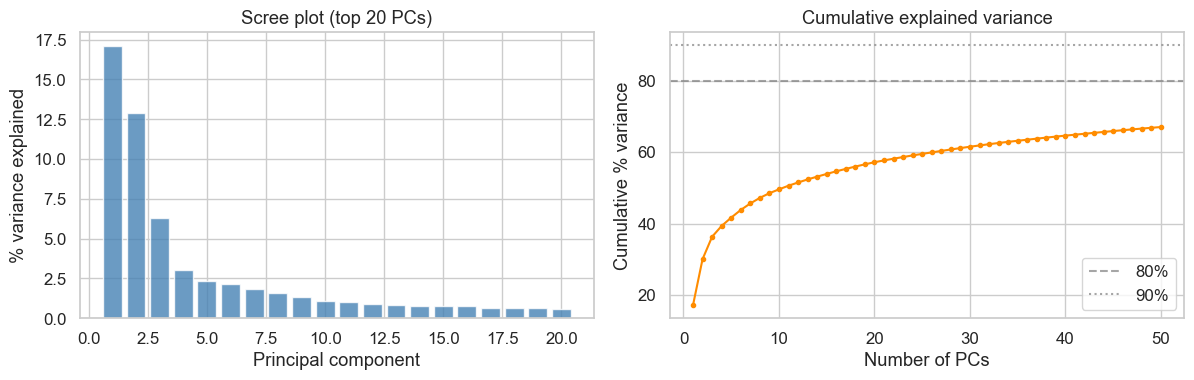

In [55]:
# ── 6a. Scree plot ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, 21), pca.explained_variance_ratio_[:20]*100, color="steelblue", alpha=0.8)
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("% variance explained")
axes[0].set_title("Scree plot (top 20 PCs)")

axes[1].plot(range(1, N_PCS+1), cum_var, marker=".", color="darkorange")
axes[1].axhline(80, color="gray", linestyle="--", alpha=0.7, label="80%")
axes[1].axhline(90, color="gray", linestyle=":",  alpha=0.7, label="90%")
axes[1].set_xlabel("Number of PCs")
axes[1].set_ylabel("Cumulative % variance")
axes[1].set_title("Cumulative explained variance")
axes[1].legend()

plt.tight_layout()
plt.show()

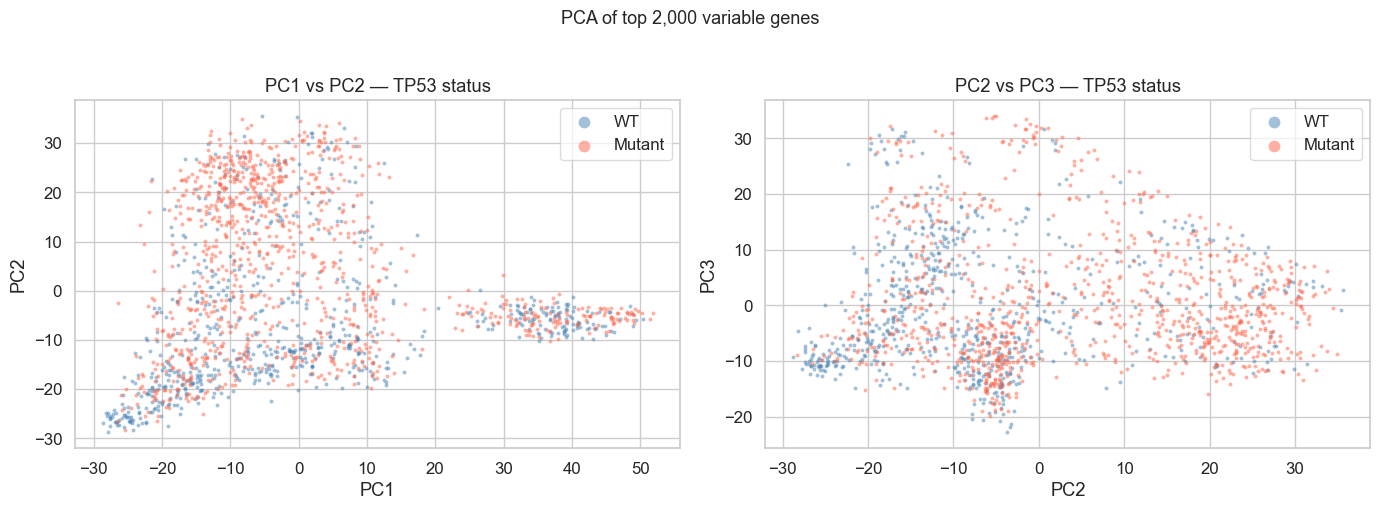

In [56]:
# ── 6b. PC1 vs PC2 coloured by TP53 binary label ─────────────────────────────
plot_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "PC3": X_pca[:, 2],
    "tp53_binary": labels["tp53_binary"].values,
    "tp53_class":  labels["tp53_class"].values,
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (pc_x, pc_y) in zip(axes, [("PC1", "PC2"), ("PC2", "PC3")]):
    for label, group in plot_df.groupby("tp53_binary"):
        ax.scatter(group[pc_x], group[pc_y],
                   c=BINARY_PALETTE[label], label=["WT", "Mutant"][label],
                   s=8, alpha=0.5, linewidths=0)
    ax.set_xlabel(pc_x)
    ax.set_ylabel(pc_y)
    ax.set_title(f"{pc_x} vs {pc_y} — TP53 status")
    ax.legend(markerscale=3, framealpha=0.7)

plt.suptitle("PCA of top 2,000 variable genes", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

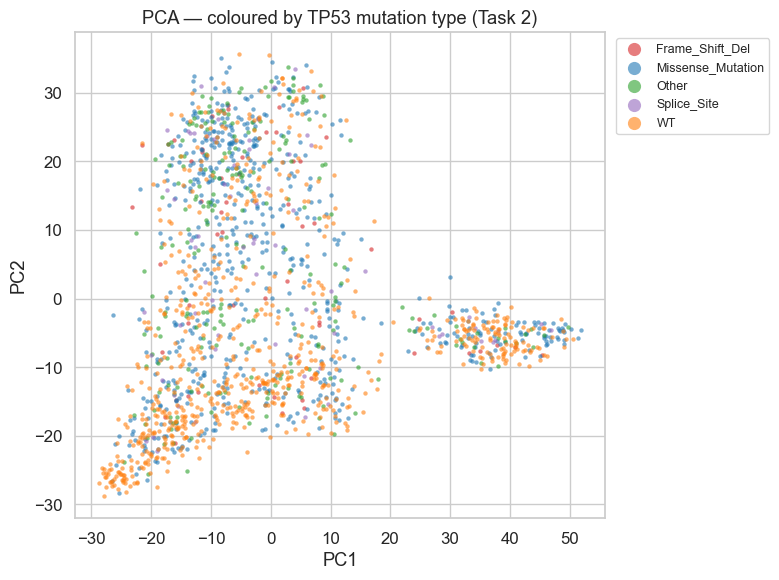

In [57]:
# ── 6c. PC1 vs PC2 coloured by mutation type (Task 2) ────────────────────────
class_palette = dict(zip(
    plot_df["tp53_class"].unique(),
    sns.color_palette("tab10", len(plot_df["tp53_class"].unique()))
))

fig, ax = plt.subplots(figsize=(8, 6))
for cls, group in plot_df.groupby("tp53_class"):
    ax.scatter(group["PC1"], group["PC2"],
               c=[class_palette[cls]], label=cls,
               s=10, alpha=0.6, linewidths=0)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA — coloured by TP53 mutation type (Task 2)")
ax.legend(markerscale=3, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

> **Key Takeaway 6**: If WT and Mutant form partially separate clouds in PC space → linear models will work well. If clusters are completely mixed → we'll need non-linear models. The multi-class plot tells us whether mutation types form distinct clusters or share the same transcriptomic space.

---
## 7. Genes Most Correlated with TP53 Status

A simple point-biserial correlation between each gene and the binary label gives us a quick sense of what signal is there — and which genes might be biological candidates.

In [58]:
y = labels["tp53_binary"].values.astype(float)

# Pearson correlation between each gene and the binary label
# (equivalent to point-biserial for binary y)
corr = pd.Series(
    [stats.pearsonr(expr.iloc[:, i].values, y)[0] for i in range(expr.shape[1])],
    index=expr.columns
)

print(f"Genes with |corr| > 0.3 : {(corr.abs() > 0.3).sum()}")
print(f"Genes with |corr| > 0.2 : {(corr.abs() > 0.2).sum()}")
print(f"Genes with |corr| > 0.1 : {(corr.abs() > 0.1).sum()}")

/var/folders/m0/s69y3ckx725_xdsv398tpyqr0000gn/T/ipykernel_64733/485184951.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  [stats.pearsonr(expr.iloc[:, i].values, y)[0] for i in range(expr.shape[1])],


Genes with |corr| > 0.3 : 38
Genes with |corr| > 0.2 : 700
Genes with |corr| > 0.1 : 5405


In [ ]:
# ── 7a. Correlation distribution ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(corr, bins=100, color="steelblue", alpha=0.8, edgecolor="none")
ax.axvline(0.3, color="tomato", linestyle="--", label="|corr|=0.3")
ax.axvline(-0.3, color="tomato", linestyle="--")
ax.set_xlabel("Pearson correlation with TP53 binary label")
ax.set_ylabel("# genes")
ax.set_title("Per-gene correlation with TP53 mutation status")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── 7b. Top 20 positively & negatively correlated genes ──────────────────────
TOP_N = 20
top_pos = corr.nlargest(TOP_N)
top_neg = corr.nsmallest(TOP_N)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, data, title, color in [
    (axes[0], top_pos, f"Top {TOP_N} positively correlated (higher in mutant)", "tomato"),
    (axes[1], top_neg, f"Top {TOP_N} negatively correlated (lower in mutant)", "steelblue")
]:
    # strip Entrez ID suffix from gene name for readability
    gene_names = [g.split(" (")[0] for g in data.index]
    ax.barh(gene_names[::-1], data.values[::-1], color=color, alpha=0.8)
    ax.set_xlabel("Pearson r")
    ax.set_title(title, fontsize=10)
    ax.axvline(0, color="black", linewidth=0.8)

plt.suptitle("Genes most correlated with TP53 mutation status", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# ── 7c. Expression violin plots for the #1 positive and #1 negative gene ─────
top1_pos = corr.idxmax()
top1_neg = corr.idxmin()

plot_label_df = labels.copy()
plot_label_df[top1_pos] = expr[top1_pos].values
plot_label_df[top1_neg] = expr[top1_neg].values

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, gene in zip(axes, [top1_pos, top1_neg]):
    gene_short = gene.split(" (")[0]
    sns.violinplot(data=plot_label_df, x="tp53_binary", y=gene,
                   hue="tp53_binary", palette=BINARY_PALETTE, legend=False,
                   ax=ax, inner="quartile")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Wild-Type", "Mutant"])
    ax.set_xlabel("")
    ax.set_ylabel("log₂(TPM + 1)")
    r = corr[gene]
    ax.set_title(f"{gene_short}  (r = {r:.3f})")

plt.suptitle("Expression of top correlated genes by TP53 status", fontsize=13)
plt.tight_layout()
plt.show()

> **Key Takeaway 7**: Strong individual correlations (|r| > 0.3) are rare in transcriptomics — the signal is spread across many genes. This motivates using regularised models (Lasso, ElasticNet) rather than selecting a handful of genes by hand. The biological identity of the top genes provides a sanity check (e.g., TP53 target genes like CDKN1A/p21 should appear).

---
## 8. Mutation Detail Analysis

Understand the landscape of TP53 mutations — variant types, functional impact, hotspots — to inform Task 2 label quality.

In [ ]:
print("Columns available in mutations table:")
print(muts.columns.tolist())

In [ ]:
# ── 8a. Mutation type breakdown ───────────────────────────────────────────────
if "VariantType" in muts.columns:
    var_type_counts = muts["VariantType"].value_counts()
    print("VariantType counts:")
    print(var_type_counts)

if "MolecularConsequence" in muts.columns:
    mc_counts = muts["MolecularConsequence"].value_counts()
    print("\nMolecularConsequence counts:")
    print(mc_counts)

In [ ]:
# ── 8b. VEP impact breakdown ─────────────────────────────────────────────────
if "VepImpact" in muts.columns:
    impact_counts = muts["VepImpact"].value_counts()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    impact_counts.plot.bar(ax=axes[0], color=sns.color_palette("muted"), edgecolor="white")
    axes[0].set_title("VEP impact categories")
    axes[0].set_xlabel("")
    axes[0].tick_params(axis="x", rotation=30)

    # Task 2 label distribution from labels dataframe
    tc = labels["tp53_class"].value_counts()
    tc.plot.bar(ax=axes[1], color=sns.color_palette("tab10", len(tc)), edgecolor="white")
    axes[1].set_title("tp53_class labels (used in Task 2)")
    axes[1].set_xlabel("")
    axes[1].tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()

In [ ]:
# ── 8c. Cell lines with multiple TP53 mutations ───────────────────────────────
if "ModelID" in muts.columns:
    muts_per_cell = muts.groupby("ModelID").size()
    print("TP53 mutations per cell line:")
    print(muts_per_cell.value_counts().sort_index().to_string())
    multi = (muts_per_cell > 1).sum()
    print(f"\nCell lines with >1 TP53 mutation: {multi} ({multi/len(muts_per_cell)*100:.1f}%)")

> **Key Takeaway 8**: Cell lines with multiple TP53 mutations need a labelling decision (take the most severe, or flag as complex). Very small mutation subtype classes may need to be merged or treated as 'other'. This will directly affect Task 2.

---
## 9. Lineage / Tissue Distribution

TP53 mutation rates vary strongly by cancer type. Confounding by lineage is a major concern — if the training split is not lineage-balanced, the model may learn tissue type, not TP53 signal.

In [ ]:
if "lineage" in labels.columns and labels["lineage"].notna().sum() > 0:
    lin_counts = labels["lineage"].value_counts().head(20)

    fig, ax = plt.subplots(figsize=(10, 5))
    lin_counts.plot.bar(ax=ax, color="steelblue", alpha=0.8, edgecolor="white")
    ax.set_xlabel("Lineage")
    ax.set_ylabel("# cell lines")
    ax.set_title("Cell line counts by lineage (top 20)")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

    # TP53 mutation rate per lineage
    lin_mut_rate = labels.groupby("lineage")["tp53_binary"].mean().sort_values(ascending=False)
    print("TP53 mutation rate per lineage (top 15):")
    print(lin_mut_rate.head(15).round(3))
else:
    print("Lineage column is missing or all-null in labels — cannot stratify by tissue.")
    print("Consider joining with the raw sample_info.csv file if available.")

> **Key Takeaway 9**: If TP53 mutation rate varies >2× across lineages (e.g., 80% in some tissues, 20% in others), lineage is a confounder. Options: (a) include lineage as a covariate, (b) stratify train/test splits by lineage, or (c) run lineage-stratified models.

---
## 10. Feature Selection Preview — How Many Genes Do We Need?

Testing whether a very small gene set retains most of the PCA variance helps us choose a practical feature count.

In [ ]:
results = []
for n in [200, 500, 1000, 2000, 5000, expr.shape[1]]:
    top_g = gene_var.nlargest(n).index
    X_sub = StandardScaler().fit_transform(expr[top_g].values)
    pca_sub = PCA(n_components=min(10, n), random_state=SEED)
    pca_sub.fit(X_sub)
    var10 = pca_sub.explained_variance_ratio_[:10].sum() * 100
    results.append({"n_genes": n, "var_top10_pcs": var10})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(results_df["n_genes"], results_df["var_top10_pcs"], marker="o", color="darkorange")
ax.set_xscale("log")
ax.set_xlabel("Number of top-variance genes used")
ax.set_ylabel("% variance explained by top 10 PCs")
ax.set_title("PCA variance retained vs. gene set size")
plt.tight_layout()
plt.show()

> **Key Takeaway 10**: If the curve flattens after ~1,000–2,000 genes we lose little information by filtering. This justifies training models on a reduced gene set — faster, less overfitting, more interpretable.

---
## 11. Summary & Modelling Decisions

Fill this in after running the cells above. Use it as your written record before moving to the modelling notebooks.

| Question | Finding | Implication |
|---|---|---|
| Missing data? | | |
| Binary class balance (WT : Mutant)? | | |
| Multi-class balance? Rare classes? | | |
| % zero expression values? | | |
| PCA separation visible? | | |
| PCs needed for 80% variance? | | |
| Strongest individual gene correlations? | | |
| Lineage confounding concern? | | |
| Recommended gene set size? | | |
| Any data quality issues? | | |